[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/danpele/MFM/blob/main/notebooks/EN/chapter1_lecture_notebook.ipynb)

# Modelling Financial Markets — Chapter 1: Stylised Facts and Returns

*Lecture notebook. Daniel Traian Pele, Bucharest University of Economic Studies.*

This notebook reproduces the main charts and tables of Lecture 1 (Sections 1–7) on real daily data:
S&P 500 (1990–2026), BET-TR (Romania, 2014–2026), Bitcoin (2014–2026), EUR/RON (BNR official reference rate, July 2005–2026) and gold (spot, 1990–2026).

> **Working in Google Colab? Save your own copy first.**
> The Colab link opens a temporary copy: when you close the tab or the session times out, your changes are lost.
> Use **File → Save a copy in Drive** (it goes to the *Colab Notebooks* folder of your ASE Google Drive) and work in that copy.
> For the team project, **File → Save a copy in GitHub** puts the notebook directly in your team's repository.
> Files you create while the notebook runs (CSV, charts) are also temporary: set `SAVE_TO_DRIVE = True` in the next cell to keep them.

In [ ]:
# Optional (Colab only): keep the files you create in Google Drive
SAVE_TO_DRIVE = False   # set to True, run this cell and allow access to your Drive

import os
OUT_DIR = '.'
if SAVE_TO_DRIVE:
    from google.colab import drive
    drive.mount('/content/drive')
    OUT_DIR = '/content/drive/MyDrive/MFM/Chapter_1'
    os.makedirs(OUT_DIR, exist_ok=True)
print('Save your outputs to:', os.path.abspath(OUT_DIR))


In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
from statsmodels.tsa.stattools import acf
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
import warnings
warnings.filterwarnings('ignore')

## Style and helpers

In [2]:
# Chart style: transparent background, legend below the plot
plt.rcParams['figure.facecolor'] = 'none'
plt.rcParams['axes.facecolor'] = 'none'
plt.rcParams['savefig.facecolor'] = 'none'
plt.rcParams['savefig.transparent'] = True
plt.rcParams['axes.grid'] = False
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Helvetica', 'Arial', 'DejaVu Sans']
plt.rcParams['font.size'] = 9
plt.rcParams['axes.labelsize'] = 10
plt.rcParams['axes.titlesize'] = 11
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.linewidth'] = 0.6
plt.rcParams['lines.linewidth'] = 1.1
plt.rcParams['legend.facecolor'] = 'none'
plt.rcParams['legend.framealpha'] = 0
plt.rcParams['legend.fontsize'] = 8

# Chart colours
MainBlue = '#1A3A6E'
IDAred   = '#CD0000'
Forest   = '#2E7D32'
Amber    = '#B5853F'
Orange   = '#E67E22'
Purple   = '#8E44AD'
Crimson  = '#DC3545'
Navy     = '#1F2A44'   # reference lines (no grey in charts)
BandBlue = '#C5D2E8'   # light MainBlue tint for confidence / reference bands
Gray, LightGray = Navy, BandBlue   # legacy names kept for importing scripts
Teal     = '#17A2B8'

ASSETS = ['sp500', 'bettr', 'btc', 'eurron', 'gold']
COLORS = {'sp500': MainBlue, 'bettr': IDAred, 'btc': Amber, 'eurron': Forest, 'gold': Purple}
PERIODS = {'sp500': 252, 'bettr': 252, 'btc': 365, 'eurron': 252, 'gold': 252}


def save_fig(name):
    """Save the figure as PDF and transparent PNG in the current folder."""
    plt.savefig(f'{name}.pdf', bbox_inches='tight', transparent=True)
    plt.savefig(f'{name}.png', bbox_inches='tight', transparent=True, dpi=180)
    plt.show()
    plt.close()
    print(f"   saved {name}")


def legend_outside_bottom(ax, ncol=2, y=-0.22):
    """Place the legend outside the plot, bottom centre."""
    ax.legend(loc='upper center', bbox_to_anchor=(0.5, y), ncol=ncol, frameon=False)



import os
import tempfile
# charts and tables go to OUT_DIR (set in the Colab cell at the top), otherwise to a temporary folder
TABLE_DIR = globals().get('OUT_DIR', tempfile.gettempdir())


def save_fig(name):
    """Save the figure to TABLE_DIR and show it."""
    plt.savefig(os.path.join(TABLE_DIR, name + '.png'), dpi=150, bbox_inches='tight', transparent=True)
    plt.show()
    plt.close()

## Data

- Daily closing prices (OHLC for the S&P 500).
- EUR/RON uses the official daily reference rate; exchange quote series contain spurious spikes.
- Returns are computed **per asset on its own calendar** (crypto trades on weekends, equities do not).

In [3]:
REPO_RAW = 'https://raw.githubusercontent.com/danpele/MFM/main/data/market/'
# local copy of the course data, if the notebook runs inside the repository
MARKET_DIR = next((os.path.join(d, 'data', 'market') for d in ('.', '..', '../..', '../../..')
                   if os.path.isdir(os.path.join(d, 'data', 'market'))), '')

SOURCES = {
    'sp500':  ('GSPC.INDX',    'close', '1990-01-01'),
    'bettr':  ('BETTR.INDX',   'close', '2014-09-01'),
    'btc':    ('BTC-USD.CC',   'close', '2014-09-17'),
    'eurron': ('REF:EUR',      'close', '2005-07-01'),   # from the introduction of the new leu (RON), 1 July 2005
    'gold':   ('XAUUSD.FOREX', 'close', '1990-01-01'),
}

LABELS = {'sp500': 'S&P 500', 'bettr': 'BET-TR (Romania)', 'btc': 'Bitcoin',
          'eurron': 'EUR/RON', 'gold': 'Gold'}

# OTC quotes (gold): partial Saturday/Sunday sessions break the Friday -> Monday return,
# so we keep weekdays only (the same convention as in Chapter 0)
WEEKDAYS_ONLY = {'gold'}

_CACHE = {}


def read_market(symbol):
    """Read the daily price table of one symbol (local copy or GitHub)."""
    fname = f'{symbol}.csv'
    path = os.path.join(MARKET_DIR, fname)
    src = path if os.path.exists(path) else REPO_RAW + fname
    df = pd.read_csv(src, parse_dates=['date']).set_index('date').sort_index()
    df.index.name = 'Date'
    return df


def read_reference_rate(currency='EUR', start='2005-07-01', end='2026-09-18'):
    """Official RON reference rate (BNR annual XML archives)."""
    key = (currency, start, end)
    if key in _CACHE:
        return _CACHE[key]
    import re
    import urllib.request
    rows = []
    for y in range(int(start[:4]), int(end[:4]) + 1):
        url = f'https://curs.bnr.ro/files/xml/years/nbrfxrates{y}.xml'
        xml = urllib.request.urlopen(urllib.request.Request(url, headers={'User-Agent': 'Mozilla'}),
                                     timeout=60).read().decode()
        for d, body in re.findall(r'<Cube date="([\d-]+)">(.*?)</Cube>', xml, re.S):
            m = re.search(rf'<Rate currency="{currency}">([\d.]+)</Rate>', body)
            if m:
                rows.append((d, float(m.group(1))))
    df = pd.DataFrame(rows, columns=['Date', 'Close']).drop_duplicates('Date').set_index('Date')
    df.index = pd.to_datetime(df.index)
    _CACHE[key] = df.sort_index().loc[start:end]
    return _CACHE[key]


def load_data(name='sp500'):
    """Daily OHLCV with columns Open/High/Low/Close/Volume (Close = the price used)."""
    symbol, col, start = SOURCES[name]
    if symbol.startswith('REF:'):
        return read_reference_rate(symbol.split(':')[1], start=start)
    d = read_market(symbol).loc[start:]
    if name in WEEKDAYS_ONLY:
        d = d[d.index.dayofweek < 5]
    out = pd.DataFrame({'Open': d['open'], 'High': d['high'], 'Low': d['low'],
                        'Close': d[col], 'Volume': d['volume']})
    return out[out['Close'] > 0].dropna(subset=['Close'])


def load_close(name):
    """Closing price, used in all charts."""
    return load_data(name)['Close'].dropna()


closes = {a: load_close(a) for a in ASSETS}
rets = {a: np.log(c).diff().dropna() for a, c in closes.items()}
# gold (weekdays only) is annualised with its actual number of observations per year
PERIODS['gold'] = len(rets['gold']) / ((closes['gold'].index[-1] - closes['gold'].index[0]).days / 365.25)
spx_ohlc = load_data('sp500')
for a in ASSETS:
    print(f'{LABELS[a]:18s}', rets[a].index[0].date(), '->', rets[a].index[-1].date(), len(rets[a]), 'obs')

S&P 500            1990-01-03 -> 2026-09-18 9245 obs
BET-TR (Romania)   2014-09-24 -> 2026-09-18 2992 obs
Bitcoin            2014-09-18 -> 2026-09-18 4384 obs
EUR/RON            2005-07-05 -> 2026-09-18 5352 obs
Gold               1990-01-03 -> 2026-09-18 9559 obs


## 1. Simple versus log returns

- $R_t = P_t/P_{t-1} - 1$ aggregates across assets; $r_t = \ln(1+R_t)$ aggregates over time.
- Bitcoin multiplied wealth by 176.9 between 2014 and 2026; the incorrect additive calculation $1 + \sum_t R_t$ gives only 8.83.

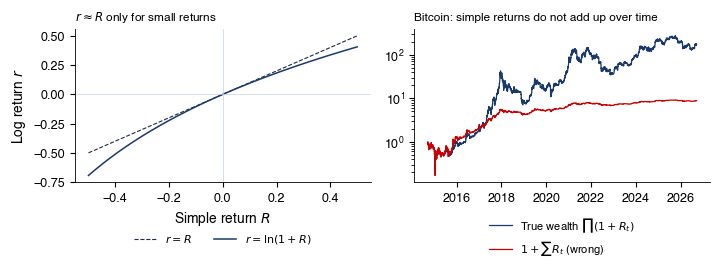

Wealth multiple: 176.9;  1 + sum(R) = 8.83;  sum(r) = 5.176


In [4]:
def fig_simple_vs_log():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    R = np.linspace(-0.5, 0.5, 400)
    axes[0].plot(R, R, color=Navy, ls='--', lw=0.8, label='$r = R$')
    axes[0].plot(R, np.log1p(R), color=MainBlue, label='$r = \\ln(1+R)$')
    axes[0].axhline(0, color=BandBlue, lw=0.5); axes[0].axvline(0, color=BandBlue, lw=0.5)
    axes[0].set_xlabel('Simple return $R$'); axes[0].set_ylabel('Log return $r$')
    axes[0].set_title('$r \\approx R$ only for small returns', fontsize=8.5, loc='left')
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.26), ncol=2, frameon=False)

    c = closes['btc']
    R_d = c.pct_change().dropna()
    axes[1].plot(c.index, c / c.iloc[0], color=MainBlue, lw=0.9, label='True wealth $\\prod(1+R_t)$')
    axes[1].plot(R_d.index, 1 + R_d.cumsum(), color=IDAred, lw=0.9, label='$1+\\sum R_t$ (wrong)')
    axes[1].set_yscale('log')
    axes[1].set_title('Bitcoin: simple returns do not add up over time', fontsize=8.5, loc='left')
    axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=1, frameon=False)
    plt.tight_layout()
    save_fig('ch1_simple_vs_log')


fig_simple_vs_log()
c = closes['btc']; R = c.pct_change().dropna()
print(f'Wealth multiple: {c.iloc[-1] / c.iloc[0]:.1f};  1 + sum(R) = {1 + R.sum():.2f};  sum(r) = {np.log(c.iloc[-1] / c.iloc[0]):.3f}')

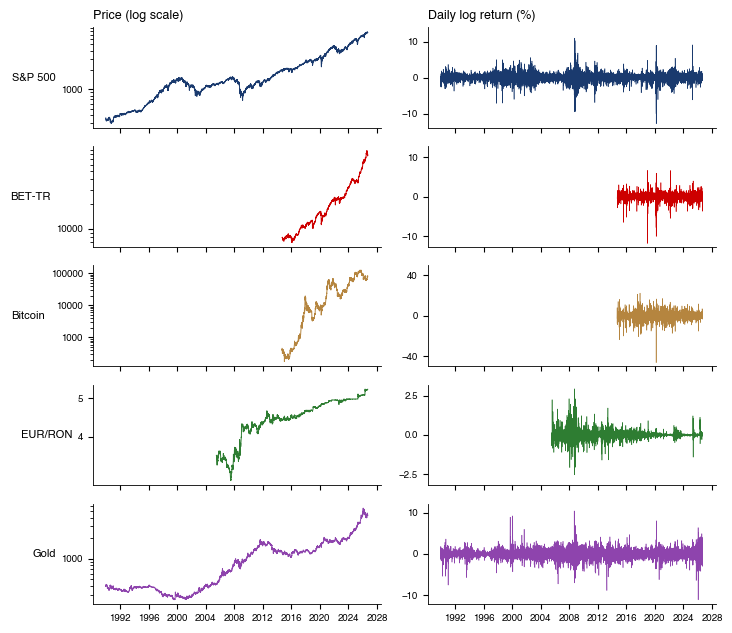

In [5]:
def fig_prices_returns():
    # one time axis for all the rows (dates only under the last row): more height for the five series
    fig, axes = plt.subplots(len(ASSETS), 2, figsize=(7.4, 6.4), sharex=True)
    from matplotlib.ticker import LogLocator, MaxNLocator
    for i, a in enumerate(ASSETS):
        c, r = closes[a], rets[a]
        axes[i, 0].plot(c.index, c.values, color=COLORS[a], lw=0.7)
        axes[i, 0].set_yscale('log')
        axes[i, 0].yaxis.set_major_locator(LogLocator(numticks=3))
        axes[i, 0].yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
        axes[i, 0].yaxis.set_minor_formatter(plt.NullFormatter())
        axes[i, 1].yaxis.set_major_locator(MaxNLocator(3, symmetric=True))
        if a == 'eurron':
            axes[i, 0].set_yticks([4, 5])
        axes[i, 0].set_ylabel(LABELS[a].replace(' (Romania)', '').replace(' (BNR)', ''), fontsize=8, rotation=0,
                              ha='right', va='center')      # horizontal: the five rows are short
        axes[i, 1].plot(r.index, 100 * r.values, color=COLORS[a], lw=0.4)
        for ax in axes[i]:
            ax.tick_params(labelsize=7)
    axes[0, 0].set_title('Price (log scale)', fontsize=9, loc='left')
    axes[0, 1].set_title('Daily log return (%)', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch1_prices_returns')


fig_prices_returns()

## 2. Descriptive statistics and tests

- Jarque–Bera (normality), Ljung–Box $Q(10)$ on $r_t$ and $r_t^2$, ARCH-LM with 5 lags.

In [6]:
def summary_table():
    rows = []
    for a in ASSETS:
        r = rets[a]
        jb = stats.jarque_bera(r)
        lb_r = acorr_ljungbox(r, lags=[10], return_df=True)
        lb_r2 = acorr_ljungbox(r ** 2, lags=[10], return_df=True)
        arch = het_arch(r - r.mean(), nlags=5)
        rows.append({
            'asset': LABELS[a], 'start': r.index[0].date(), 'end': r.index[-1].date(), 'N': len(r),
            'mean_daily_pct': 100 * r.mean(), 'sd_daily_pct': 100 * r.std(),
            'ann_vol_pct': 100 * r.std() * np.sqrt(PERIODS[a]),
            'skew': stats.skew(r), 'exkurt': stats.kurtosis(r),
            'min_pct': 100 * r.min(), 'max_pct': 100 * r.max(),
            'JB': jb.statistic, 'JB_p': jb.pvalue,
            'LB10_r': lb_r['lb_stat'].iloc[0], 'LB10_r_p': lb_r['lb_pvalue'].iloc[0],
            'LB10_r2': lb_r2['lb_stat'].iloc[0], 'LB10_r2_p': lb_r2['lb_pvalue'].iloc[0],
            'ARCH5': arch[0], 'ARCH5_p': arch[1],
        })
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_summary_statistics.csv'), float_format='%.6g')
    return t


summary_table().T

asset,S&P 500,BET-TR (Romania),Bitcoin,EUR/RON,Gold
start,1990-01-03,2014-09-24,2014-09-18,2005-07-05,1990-01-03
end,2026-09-18,2026-09-18,2026-09-18,2026-09-18,2026-09-18
N,9245,2992,4384,5352,9559
mean_daily_pct,0.03307,0.077116,0.118056,0.007108,0.025052
sd_daily_pct,1.133365,0.977644,3.485192,0.279412,1.011535
ann_vol_pct,17.991617,15.519616,66.584504,4.435522,16.323017
skew,-0.363645,-1.399928,-0.704892,0.725478,-0.231138
exkurt,10.880296,17.790052,11.95772,15.138516,9.326799
min_pct,-12.765218,-11.857201,-46.473021,-2.540081,-11.140951
max_pct,10.957196,6.706696,22.511895,2.927243,10.437101


## 3. Heavy tails, asymmetry and aggregation

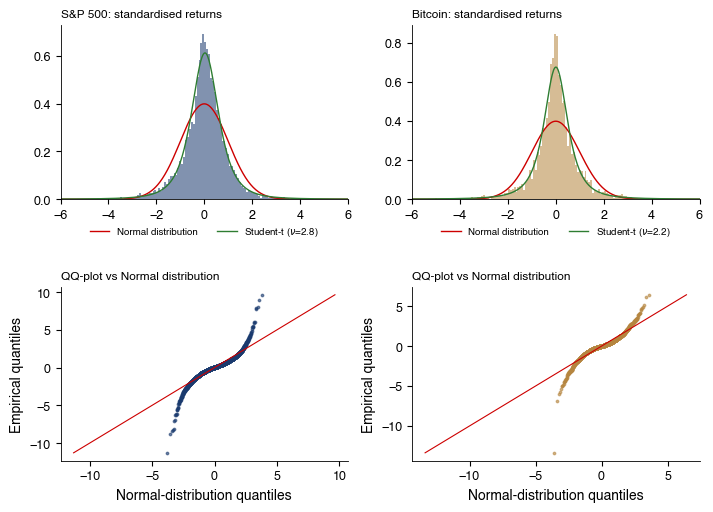

In [7]:
def fig_hist_qq():
    fig, axes = plt.subplots(2, 2, figsize=(7.2, 5.2))
    for j, a in enumerate(['sp500', 'btc']):
        r = rets[a]
        z = (r - r.mean()) / r.std()
        ax = axes[0, j]
        ax.hist(z, bins=200, density=True, color=COLORS[a], alpha=0.55, range=(-8, 8))
        x = np.linspace(-8, 8, 600)
        ax.plot(x, stats.norm.pdf(x), color=IDAred, lw=1.0, label='Normal distribution')
        nu, loc, sc = stats.t.fit(z)
        ax.plot(x, stats.t.pdf(x, nu, loc, sc), color=Forest, lw=1.0, label=f'Student-t ($\\nu$={nu:.1f})')
        ax.set_xlim(-6, 6)
        ax.set_title(f'{LABELS[a]}: standardised returns', fontsize=8.5, loc='left')
        ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2, frameon=False, fontsize=7)
        ax2 = axes[1, j]
        (osm, osr), _ = stats.probplot(z, dist='norm')
        ax2.scatter(osm, osr, s=3, color=COLORS[a], alpha=0.6)
        lim = [min(osm.min(), osr.min()), max(osm.max(), osr.max())]
        ax2.plot(lim, lim, color=IDAred, lw=0.8)
        ax2.set_xlabel('Normal-distribution quantiles'); ax2.set_ylabel('Empirical quantiles')
        ax2.set_title('QQ-plot vs Normal distribution', fontsize=8.5, loc='left')
    plt.tight_layout(h_pad=2.2)
    save_fig('ch1_hist_qq')


fig_hist_qq()

In [8]:
# Tail counts and Student-t degrees of freedom
rows = []
for a in ASSETS:
    r = rets[a]; z = (r - r.mean()) / r.std()
    nu = stats.t.fit(z)[0]
    rows.append({'asset': LABELS[a], '>3sd %': 100 * (z.abs() > 3).mean(), '>5sd': int((z.abs() > 5).sum()),
                 'Normal distribution >5sd': len(r) * 2 * stats.norm.sf(5), 'nu': nu})
pd.DataFrame(rows).set_index('asset').round(3)

,>3sd %,>5sd,Normal distribution >5sd,nu
asset,,,,
S&P 500,1.547,30,0.005,2.815
BET-TR (Romania),1.437,12,0.002,3.097
Bitcoin,1.825,10,0.003,2.229
EUR/RON,2.055,29,0.003,1.249
Gold,1.423,26,0.005,2.859


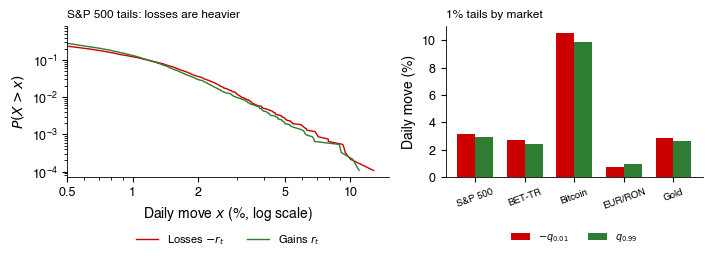

,1% loss,99% gain
S&P 500,3.15,2.97
BET-TR,2.73,2.40
Bitcoin,10.51,9.87
EUR/RON,0.76,0.94
Gold,2.85,2.67


In [9]:
def fig_gain_loss():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9), gridspec_kw={'width_ratios': [1.25, 1]})
    r = rets['sp500']
    for s, c, lab in [(-r[r < 0], IDAred, 'Losses $-r_t$'), (r[r > 0], Forest, 'Gains $r_t$')]:
        x = np.sort(s.values)[::-1]
        surv = np.arange(1, len(x) + 1) / len(r)
        axes[0].loglog(100 * x, surv, color=c, lw=1.0, label=lab)
    axes[0].set_xlim(0.5, 15)
    axes[0].set_xticks([0.5, 1, 2, 5, 10])
    axes[0].xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    axes[0].xaxis.set_minor_formatter(plt.NullFormatter())
    axes[0].set_xlabel('Daily move $x$ (%, log scale)'); axes[0].set_ylabel('$P(X > x)$')
    axes[0].set_title('S&P 500 tails: losses are heavier', fontsize=8.5, loc='left')
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False)
    q = pd.DataFrame({LABELS[a].replace(' (Romania)', '').replace(' (BNR)', ''): [-100 * rets[a].quantile(0.01), 100 * rets[a].quantile(0.99)]
                      for a in ASSETS}, index=['1% loss', '99% gain']).T
    x = np.arange(len(q))
    axes[1].bar(x - 0.18, q['1% loss'], 0.36, color=IDAred, label='$-q_{0.01}$')
    axes[1].bar(x + 0.18, q['99% gain'], 0.36, color=Forest, label='$q_{0.99}$')
    axes[1].set_xticks(x, q.index, fontsize=7, rotation=20)
    axes[1].set_ylabel('Daily move (%)')
    axes[1].set_title('1% tails by market', fontsize=8.5, loc='left')
    axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, -0.3), ncol=2, frameon=False, fontsize=7)
    plt.tight_layout()
    save_fig('ch1_gain_loss')
    return q


fig_gain_loss().round(2)

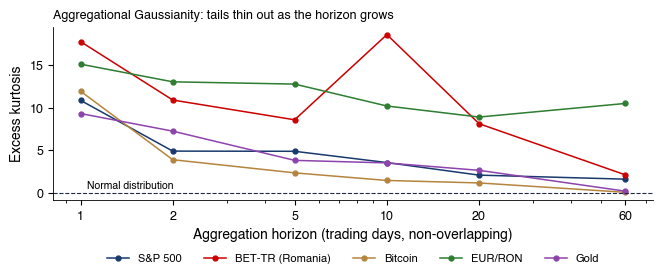

,sp500,bettr,btc,eurron,gold
1,10.88,17.79,11.96,15.14,9.33
2,4.91,10.92,3.89,13.06,7.25
5,4.89,8.59,2.35,12.79,3.82
10,3.56,18.61,1.45,10.21,3.52
20,2.08,8.13,1.16,8.91,2.64
60,1.61,2.12,0.06,10.51,0.20


In [10]:
HORIZONS = [1, 2, 5, 10, 20, 60]


def aggregation_kurtosis():
    out = {}
    for a in ASSETS:
        r = rets[a]
        ks = []
        for h in HORIZONS:
            m = (len(r) // h) * h                                # complete h-day windows only
            agg = r.iloc[:m].groupby(np.arange(m) // h).sum()   # non-overlapping sums
            ks.append(stats.kurtosis(agg))
        out[a] = ks
    return pd.DataFrame(out, index=HORIZONS)


def fig_aggregation():
    k = aggregation_kurtosis()
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    for a in ASSETS:
        ax.plot(HORIZONS, k[a], marker='o', ms=3.5, color=COLORS[a], label=LABELS[a])
    ax.axhline(0, color=Navy, ls='--', lw=0.8)
    ax.text(1.05, 0.5, 'Normal distribution', color='black', fontsize=7.5, ha='left')
    ax.set_xscale('log'); ax.set_xticks(HORIZONS, [str(h) for h in HORIZONS])
    ax.set_xlabel('Aggregation horizon (trading days, non-overlapping)')
    ax.set_ylabel('Excess kurtosis')
    ax.set_title('Aggregational Gaussianity: tails thin out as the horizon grows', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_aggregation_kurtosis')
    k.to_csv(os.path.join(TABLE_DIR, 'ch1_aggregation_kurtosis.csv'), float_format='%.4g')
    return k


fig_aggregation().round(2)

### Tail index: the Hill estimator

- $\hat\alpha_k = [\frac1k\sum_{i=1}^k \ln X_{(i)} - \ln X_{(k+1)}]^{-1}$ on the $k$ largest absolute returns.
- Moments of order $< \alpha$ exist; $\alpha < 4$ means the population kurtosis does not exist.
- The Student-t $\hat\nu$ above is a model-based tail index fitted to the whole distribution: valid only if the Student-t fits centre and tails together; Hill uses only the tail.

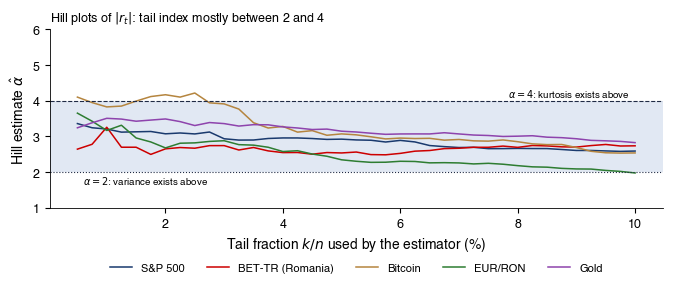

,n,k,alpha_abs,alpha_loss,alpha_gain,alpha_abs_min_1to5pct,alpha_abs_max_1to5pct
asset,,,,,,,
S&P 500,9245,231,3.07,2.97,2.96,2.93,3.21
BET-TR (Romania),2992,74,2.67,2.19,3.06,2.54,3.26
Bitcoin,4384,109,4.22,2.71,3.37,3.07,4.22
EUR/RON,5352,133,2.82,2.63,2.30,2.35,3.17
Gold,9559,238,3.31,3.00,3.28,3.15,3.51


In [11]:
HILL_FRACS = np.round(np.arange(0.005, 0.1001, 0.0025), 4)


def hill_estimator(x, k):
    """alpha_hat(k) = [ (1/k) sum_{i=1..k} ln(X_(i) / X_(k+1)) ]^{-1}, X_(1) >= X_(2) >= ..."""
    x = np.sort(np.asarray(x)[np.asarray(x) > 0])[::-1]
    return 1.0 / np.mean(np.log(x[:k] / x[k]))


def hill_table(frac=0.025):
    """Hill tail index for |r_t|, losses (-r_t) and gains (r_t) at k = frac * n."""
    rows = []
    for a in ASSETS:
        r = rets[a].values
        k = int(frac * len(r))
        rows.append({'asset': LABELS[a], 'n': len(r), 'k': k,
                     'alpha_abs': hill_estimator(np.abs(r), k),
                     'alpha_loss': hill_estimator(-r, k), 'alpha_gain': hill_estimator(r, k),
                     'alpha_abs_min_1to5pct': min(hill_estimator(np.abs(r), int(f * len(r))) for f in (0.01, 0.025, 0.05)),
                     'alpha_abs_max_1to5pct': max(hill_estimator(np.abs(r), int(f * len(r))) for f in (0.01, 0.025, 0.05))})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_hill.csv'), float_format='%.4g')
    return t


def fig_hill():
    fig, ax = plt.subplots(figsize=(6.8, 3.1))
    for a in ASSETS:
        r = np.abs(rets[a].values)
        al = [hill_estimator(r, max(int(f * len(r)), 5)) for f in HILL_FRACS]
        ax.plot(100 * HILL_FRACS, al, color=COLORS[a], lw=1.1, label=LABELS[a])
    ax.axhspan(2, 4, color=BandBlue, alpha=0.5, lw=0)
    ax.axhline(4, color=Navy, ls='--', lw=0.8)
    ax.axhline(2, color=Navy, ls=':', lw=0.8)
    ax.text(9.9, 4.05, r'$\alpha = 4$: kurtosis exists above', fontsize=7, color='black', ha='right', va='bottom')
    ax.text(0.6, 1.95, r'$\alpha = 2$: variance exists above', fontsize=7, color='black', ha='left', va='top')
    ax.set_xlabel('Tail fraction $k/n$ used by the estimator (%)')
    ax.set_ylabel(r'Hill estimate $\hat\alpha$')
    ax.set_ylim(1, 6)
    ax.set_title('Hill plots of $|r_t|$: tail index mostly between 2 and 4', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_hill_plot')


fig_hill()
hill_table().round(2)

### Inference under heavy tails and dependence

- Quantile-based skewness (Hinkley) and kurtosis (Crow–Siddiqui) with moving-block bootstrap intervals.
- Lag-1 autocorrelation with the heteroskedasticity-robust band; Hill indices with i.i.d. and block-bootstrap standard errors; both tails at a common threshold.

In [12]:
def moving_block_indices(T, block, rng):
    """Indices of one moving-block bootstrap sample with blocks of length `block`."""
    nb = int(np.ceil(T / block))
    st = rng.integers(0, T - block + 1, nb)      # all T - block + 1 valid block starts
    return (st[:, None] + np.arange(block)[None, :]).ravel()[:T]


def robust_moments(n_boot=1000, block=20, seed=42):
    """Quantile-based skewness and kurtosis (Kim & White 2004): Hinkley (5%-95%) and Crow-Siddiqui
    (2.5%, 97.5% relative to the quartiles, minus 2.91, the value for the Normal distribution); block-bootstrap CIs."""
    def qstats(v):
        q = np.quantile(v, [0.025, 0.05, 0.25, 0.5, 0.75, 0.95, 0.975])
        return ((q[5] + q[1] - 2 * q[3]) / (q[5] - q[1]), (q[6] - q[0]) / (q[4] - q[2]) - 2.91)
    rng = np.random.default_rng(seed)
    rows = []
    for a in ASSETS:
        v = rets[a].values
        sk, ku = qstats(v)
        b = np.array([qstats(v[moving_block_indices(len(v), block, rng)]) for _ in range(n_boot)])
        rows.append({'asset': LABELS[a], 'skew_moment': stats.skew(v), 'skew_hinkley': sk,
                     'skew_lo': np.quantile(b[:, 0], 0.025), 'skew_hi': np.quantile(b[:, 0], 0.975),
                     'exkurt_moment': stats.kurtosis(v), 'kurt_cs': ku,
                     'kurt_lo': np.quantile(b[:, 1], 0.025), 'kurt_hi': np.quantile(b[:, 1], 0.975)})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_robust_moments.csv'), float_format='%.4g')
    return t


def acf_robust_lag1():
    """rho_1 with the i.i.d. band 1.96/sqrt(T) and the robust band 1.96 sqrt(tau_1) (Romano & Thombs 1996)."""
    rows = []
    for a in ASSETS:
        x = (rets[a] - rets[a].mean()).values
        T, s2 = len(x), np.sum(x ** 2)
        rho = np.sum(x[1:] * x[:-1]) / s2
        tau = np.sum(x[1:] ** 2 * x[:-1] ** 2) / s2 ** 2
        rows.append({'asset': LABELS[a], 'T': T, 'rho1': rho, 'T_tau1': T * tau, 'band_iid': 1.96 / np.sqrt(T),
                     'band_robust': 1.96 * np.sqrt(tau), 't_iid': rho * np.sqrt(T), 't_robust': rho / np.sqrt(tau)})
    return pd.DataFrame(rows).set_index('asset')


def hill_threshold(x, u):
    """Hill with a fixed threshold u: k = #{x > u}, alpha_hat = k / sum ln(x_i / u) over x_i > u."""
    x = np.asarray(x)
    e = x[x > u]
    return len(e) / np.sum(np.log(e / u))


def hill_inference(frac=0.025, n_boot=500, block=20, seed=42):
    """Hill for |r_t| at k = frac*n: i.i.d. CI alpha(1 +/- 1.96/sqrt(k)), block-bootstrap SE,
    and the comparison with the one-sided tails at the SAME threshold u (min of the one-sided thresholds)."""
    rng = np.random.default_rng(seed)
    rows = []
    for a in ASSETS:
        r = rets[a].values
        n = len(r)
        k = int(frac * n)
        al = hill_estimator(np.abs(r), k)
        boot = [hill_estimator(np.abs(r)[moving_block_indices(n, block, rng)], k) for _ in range(n_boot)]
        u = min(np.sort(-r)[::-1][k], np.sort(r)[::-1][k])
        kL, kG, kA = int((-r > u).sum()), int((r > u).sum()), int((np.abs(r) > u).sum())
        rows.append({'asset': LABELS[a], 'n': n, 'k': k, 'alpha_abs': al, 'se_iid': al / np.sqrt(k),
                     'se_block': np.std(boot, ddof=1), 'ci_lo': al * (1 - 1.96 / np.sqrt(k)),
                     'ci_hi': al * (1 + 1.96 / np.sqrt(k)), 'alpha_loss_k': hill_estimator(-r, k),
                     'alpha_gain_k': hill_estimator(r, k), 'u_common_pct': 100 * u, 'k_abs_u': kA,
                     'alpha_abs_u': hill_threshold(np.abs(r), u), 'alpha_loss_u': hill_threshold(-r, u),
                     'alpha_gain_u': hill_threshold(r, u)})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_hill_inference.csv'), float_format='%.4g')
    return t


print(robust_moments().round(3).T)
print(acf_robust_lag1().round(3).T)
hill_inference().round(3).T

asset          S&P 500  BET-TR (Romania)  Bitcoin  EUR/RON   Gold
skew_moment     -0.364            -1.400   -0.705    0.725 -0.231
skew_hinkley    -0.064            -0.036   -0.018    0.041  0.004
skew_lo         -0.092            -0.085   -0.069   -0.022 -0.025
skew_hi         -0.041             0.025    0.032    0.093  0.030
exkurt_moment   10.880            17.790   11.958   15.139  9.327
kurt_cs          1.540             1.057    2.246    4.868  1.468
kurt_lo          1.289             0.734    1.884    3.738  1.288
kurt_hi          1.790             1.432    2.637    6.129  1.730
asset         S&P 500  BET-TR (Romania)   Bitcoin   EUR/RON      Gold
T            9245.000          2992.000  4384.000  5352.000  9559.000
rho1           -0.079             0.061    -0.022     0.170    -0.011
T_tau1          5.000             4.354     2.894     6.851     2.432
band_iid        0.020             0.036     0.030     0.027     0.020
band_robust     0.046             0.075     0.050     0.

asset,S&P 500,BET-TR (Romania),Bitcoin,EUR/RON,Gold
n,9245.000,2992.000,4384.000,5352.000,9559.000
k,231.000,74.000,109.000,133.000,238.000
alpha_abs,3.072,2.672,4.218,2.822,3.307
se_iid,0.202,0.311,0.404,0.245,0.214
se_block,0.327,0.449,0.473,0.280,0.244
ci_lo,2.676,2.063,3.426,2.342,2.887
ci_hi,3.468,3.281,5.009,3.301,3.727
alpha_loss_k,2.972,2.188,2.706,2.630,2.997
alpha_gain_k,2.957,3.057,3.368,2.301,3.277
u_common_pct,2.169,1.785,7.108,0.538,1.976


## 4. Volatility clustering, long memory and the Taylor effect

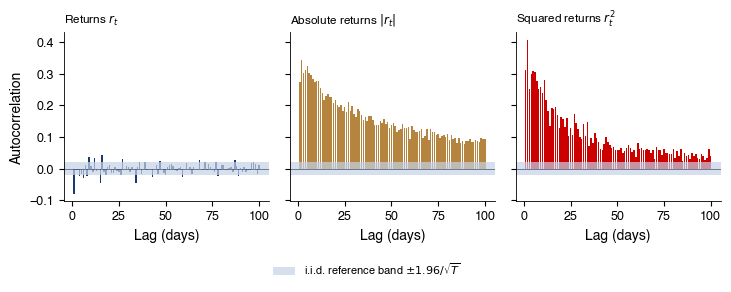

In [13]:
def fig_acf_sp500(nlags=100):
    r = rets['sp500']
    band = 1.96 / np.sqrt(len(r))
    series = [(r, 'Returns $r_t$', MainBlue), (r.abs(), 'Absolute returns $|r_t|$', Amber),
              (r ** 2, 'Squared returns $r_t^2$', IDAred)]
    fig, axes = plt.subplots(1, 3, figsize=(7.4, 2.6), sharey=True)
    for ax, (s, t, c) in zip(axes, series):
        a = acf(s, nlags=nlags, fft=True)[1:]
        ax.bar(range(1, nlags + 1), a, color=c, width=0.8)
        ax.axhspan(-band, band, color=BandBlue, alpha=0.7, lw=0, label='i.i.d. reference band $\\pm1.96/\\sqrt{T}$')
        ax.axhline(0, color=Navy, lw=0.4)
        ax.set_title(t, fontsize=8.5, loc='left')
        ax.set_xlabel('Lag (days)')
    axes[0].set_ylabel('Autocorrelation')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=1, frameon=False)
    plt.tight_layout()
    save_fig('ch1_acf_sp500')


fig_acf_sp500()

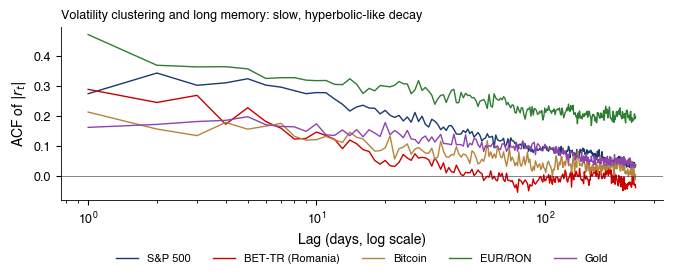

,sp500,bettr,btc,eurron,gold
1,0.274,0.289,0.213,0.472,0.161
5,0.324,0.227,0.155,0.357,0.197
20,0.218,0.051,0.093,0.299,0.178
100,0.093,-0.017,0.024,0.226,0.105
250,0.037,-0.040,0.003,0.196,0.032


In [14]:
def fig_acf_abs_assets(nlags=250):
    fig, ax = plt.subplots(figsize=(6.8, 3.0))
    out = {}
    for a in ASSETS:
        ac = acf(rets[a].abs(), nlags=nlags, fft=True)[1:]
        out[a] = ac
        ax.plot(range(1, nlags + 1), ac, color=COLORS[a], lw=1.0, label=LABELS[a])
    ax.set_xscale('log')
    ax.axhline(0, color=Navy, lw=0.4)
    ax.set_xlabel('Lag (days, log scale)')
    ax.set_ylabel('ACF of $|r_t|$')
    ax.set_title('Volatility clustering and long memory: slow, hyperbolic-like decay', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_acf_abs_assets')
    return pd.DataFrame(out, index=range(1, nlags + 1))


fig_acf_abs_assets().loc[[1, 5, 20, 100, 250]].round(3)

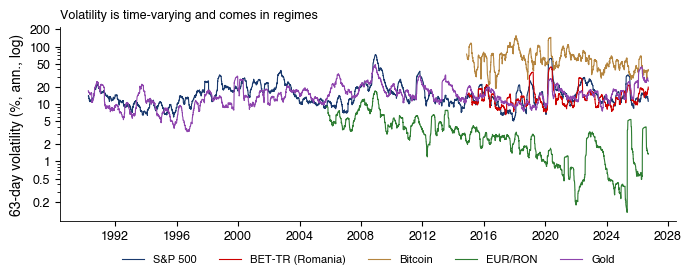

In [15]:
def fig_rolling_vol():
    fig, ax = plt.subplots(figsize=(7.0, 2.9))
    for a in ASSETS:
        v = rets[a].rolling(63).std() * np.sqrt(PERIODS[a]) * 100
        ax.plot(v.index, v, color=COLORS[a], lw=0.8, label=LABELS[a])
    ax.set_yscale('log')
    ax.set_yticks([0.2, 0.5, 1, 2, 5, 10, 20, 50, 100, 200])
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.yaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_ylabel('63-day volatility (%, ann., log)')
    ax.set_title('Volatility is time-varying and comes in regimes', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=5, y=-0.12)
    plt.tight_layout()
    save_fig('ch1_rolling_vol')


fig_rolling_vol()

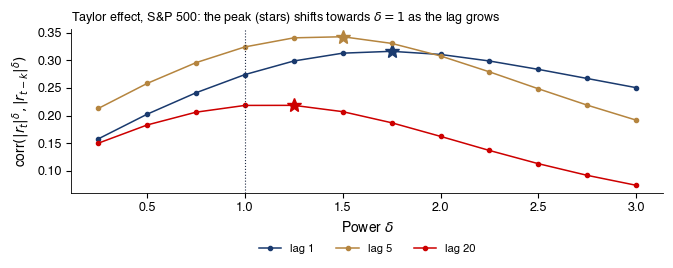

,1,5,20
0.25,0.158,0.213,0.150
0.50,0.203,0.258,0.183
0.75,0.241,0.296,0.206
1.00,0.274,0.324,0.218
1.25,0.299,0.341,0.219
1.50,0.313,0.343,0.207
1.75,0.316,0.331,0.187
2.00,0.311,0.308,0.162
2.25,0.299,0.279,0.137
2.50,0.284,0.249,0.113


In [16]:
def fig_taylor():
    deltas = np.round(np.arange(0.25, 3.01, 0.25), 2)
    fig, ax = plt.subplots(figsize=(6.8, 2.9))
    out = {}
    for lag, c in zip([1, 5, 20], [MainBlue, Amber, IDAred]):
        vals = [acf(rets['sp500'].abs() ** d, nlags=lag, fft=True)[lag] for d in deltas]
        out[lag] = vals
        ax.plot(deltas, vals, marker='o', ms=3, color=c, label=f'lag {lag}')
        ax.plot(deltas[np.argmax(vals)], max(vals), marker='*', ms=10, color=c)
    ax.axvline(1, color=Navy, ls=':', lw=0.8)
    ax.set_xlabel('Power $\\delta$')
    ax.set_ylabel('corr$(|r_t|^\\delta, |r_{t-k}|^\\delta)$')
    ax.set_title('Taylor effect, S&P 500: the peak (stars) shifts towards $\\delta = 1$ as the lag grows',
                 fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.25)
    plt.tight_layout()
    save_fig('ch1_taylor_effect')
    return pd.DataFrame(out, index=deltas)


fig_taylor().round(3)

### Estimating the memory parameter d, and breaks

- Local Whittle and log-periodogram estimates of d for |r_t|, m = T^0.65; re-estimation on each side of a variance break located by the cumulative sum of squares.

In [17]:
def periodogram(x):
    x = np.asarray(x) - np.mean(x)
    T = len(x)
    return 2 * np.pi * np.arange(T) / T, np.abs(np.fft.fft(x)) ** 2 / (2 * np.pi * T)


def local_whittle(x, m):
    """Robinson (1995): d minimises R(d) = ln(mean(lambda_j^{2d} I_j)) - 2d mean(ln lambda_j); SE = 1/(2 sqrt m)."""
    from scipy.optimize import minimize_scalar
    lam, I = periodogram(x)
    l, Ij = lam[1:m + 1], I[1:m + 1]
    R = lambda d: np.log(np.mean(l ** (2 * d) * Ij)) - 2 * d * np.mean(np.log(l))
    return minimize_scalar(R, bounds=(-0.49, 0.99), method='bounded').x, 1 / (2 * np.sqrt(m))


def gph(x, m):
    """Geweke & Porter-Hudak (1983): slope of ln I_j on -2 ln(2 sin(lambda_j/2)); SE = pi/sqrt(24 m)."""
    lam, I = periodogram(x)
    X = -2 * np.log(2 * np.sin(lam[1:m + 1] / 2))
    return np.polyfit(X, np.log(I[1:m + 1]), 1)[0], np.pi / np.sqrt(24 * m)


def cusum_squares_break(r):
    """Date of the break in the unconditional variance: argmax |C_k/C_T - k/T| (Inclan & Tiao 1994)."""
    x = np.asarray(r) - np.mean(r)
    C = np.cumsum(x ** 2)
    T = len(x)
    D = C / C[-1] - np.arange(1, T + 1) / T
    j = int(np.argmax(np.abs(D)))
    return j, np.sqrt(T / 2) * np.abs(D[j])


def long_memory_table(power=0.65):
    """d for |r_t|: local Whittle and GPH with m = T^0.65; then re-estimation on each side
    of the estimated variance break (the 'long memory or breaks?' check)."""
    rows = []
    for a in ASSETS:
        r = rets[a]
        x = np.abs(r.values)
        T = len(x)
        m = int(T ** power)
        dlw, slw = local_whittle(x, m)
        dg, sg = gph(x, m)
        j, it = cusum_squares_break(r.values)
        pre, post = x[:j + 1], x[j + 1:]
        dpre, spre = local_whittle(pre, int(len(pre) ** power))
        dpost, spost = local_whittle(post, int(len(post) ** power))
        P = PERIODS[a]
        rows.append({'asset': LABELS[a], 'T': T, 'm': m, 'd_lw': dlw, 'se_lw': slw, 'd_gph': dg, 'se_gph': sg,
                     'break_date': r.index[j].date(), 'IT_stat': it,
                     'vol_pre_pct': 100 * r.values[:j + 1].std() * np.sqrt(P),
                     'vol_post_pct': 100 * r.values[j + 1:].std() * np.sqrt(P),
                     'd_pre': dpre, 'se_pre': spre, 'd_post': dpost, 'se_post': spost})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_long_memory.csv'), float_format='%.4g')
    return t


long_memory_table().round(3).T

asset,S&P 500,BET-TR (Romania),Bitcoin,EUR/RON,Gold
T,9245,2992,4384,5352,9559
m,378,181,232,265,386
d_lw,0.481,0.373,0.353,0.393,0.4
se_lw,0.026,0.037,0.033,0.031,0.025
d_gph,0.495,0.41,0.354,0.381,0.424
se_gph,0.033,0.048,0.042,0.039,0.033
break_date,1998-07-20,2018-12-17,2022-06-19,2013-06-27,2005-11-29
IT_stat,8.126,4.746,8.075,23.983,10.291
vol_pre_pct,12.569,12.534,74.939,6.61,13.219
vol_post_pct,19.342,16.925,47.672,2.23,18.339


## 5. Leverage effect and volume

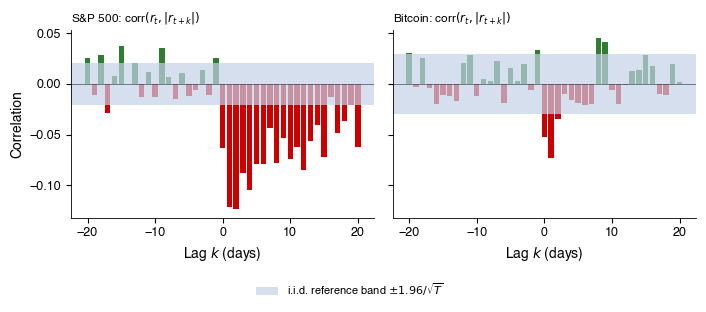

,sp500,btc
-5,-0.012,0.016
-1,0.026,0.033
0,-0.063,-0.052
1,-0.121,-0.073
5,-0.079,-0.018
10,-0.074,-0.006


In [18]:
def leverage_corr(r, K=20):
    ks = np.arange(-K, K + 1)
    a = r.abs()
    return ks, np.array([r.corr(a.shift(-k)) for k in ks])     # corr(r_t, |r_{t+k}|)


def fig_leverage():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.8), sharey=True)
    out = {}
    for ax, a in zip(axes, ['sp500', 'btc']):
        ks, c = leverage_corr(rets[a])
        out[a] = pd.Series(c, index=ks)
        ax.bar(ks, c, color=np.where(c < 0, IDAred, Forest), width=0.8)
        band = 1.96 / np.sqrt(len(rets[a]))
        ax.axhspan(-band, band, color=BandBlue, alpha=0.7, lw=0, label='i.i.d. reference band $\\pm1.96/\\sqrt{T}$')
        ax.axhline(0, color=Navy, lw=0.4)
        ax.set_xlabel('Lag $k$ (days)')
        ax.set_title(f'{LABELS[a]}: corr$(r_t, |r_{{t+k}}|)$', fontsize=8.5, loc='left')
    axes[0].set_ylabel('Correlation')
    h, l = axes[0].get_legend_handles_labels()
    fig.legend(h, l, loc='upper center', bbox_to_anchor=(0.5, 0.02), ncol=1, frameon=False)
    plt.tight_layout()
    save_fig('ch1_leverage')
    return pd.DataFrame(out)


fig_leverage().loc[[-5, -1, 0, 1, 5, 10]].round(3)

In [19]:
# Leverage effect at k = 1 for all markets
{LABELS[a]: round(rets[a].corr(rets[a].abs().shift(-1)), 3) for a in ASSETS}

{'S&P 500': np.float64(-0.121),
 'BET-TR (Romania)': np.float64(-0.118),
 'Bitcoin': np.float64(-0.073),
 'EUR/RON': np.float64(0.1),
 'Gold': np.float64(-0.015)}

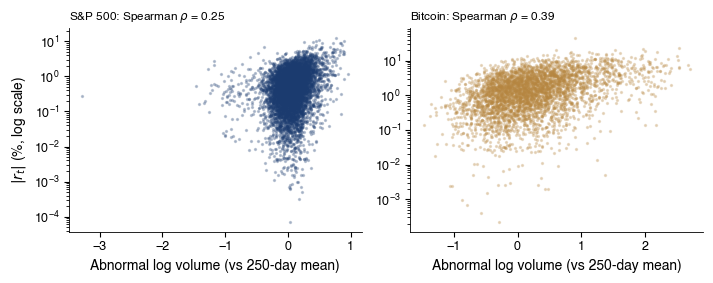

{'sp500': np.float64(0.2489989310265099),
 'btc': np.float64(0.3918580189262263)}

In [20]:
def fig_volume_volatility():
    fig, axes = plt.subplots(1, 2, figsize=(7.2, 2.9))
    res = {}
    for ax, a in zip(axes, ['sp500', 'btc']):
        d = load_data(a)
        v = np.log(d['Volume'].replace(0, np.nan))
        v_rel = (v - v.rolling(250).mean()).dropna()               # abnormal (detrended) volume
        r_abs = np.log(d['Close']).diff().abs()
        df = pd.DataFrame({'v': v_rel, 'a': r_abs}).dropna()
        df = df[df['a'] > 0]
        rho = stats.spearmanr(df['v'], df['a'])[0]
        res[a] = rho
        ax.scatter(df['v'], 100 * df['a'], s=2, color=COLORS[a], alpha=0.25)
        ax.set_yscale('log')
        ax.set_xlabel('Abnormal log volume (vs 250-day mean)')
        ax.set_title(f'{LABELS[a]}: Spearman $\\rho$ = {rho:.2f}', fontsize=8.5, loc='left')
    axes[0].set_ylabel('$|r_t|$ (%, log scale)')
    plt.tight_layout()
    save_fig('ch1_volume_volatility')
    return res


fig_volume_volatility()

## 6. Range-based volatility estimators

- S&P 500 opens before 2007 equal the previous close, so the comparison starts in 2008.

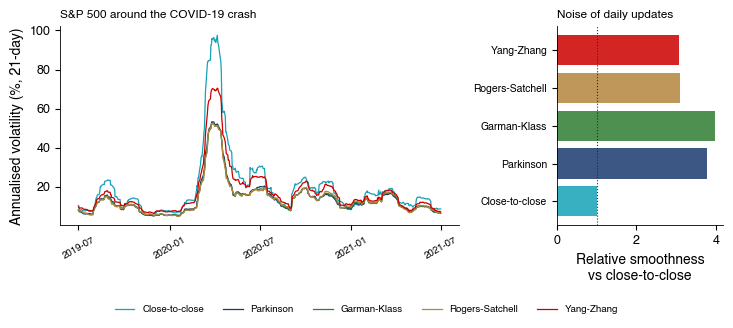

,mean_pct,rel_smoothness
Close-to-close,16.352,1.000
Parkinson,12.996,3.776
Garman-Klass,12.440,3.985
Rogers-Satchell,12.320,3.097
Yang-Zhang,13.886,3.080


In [21]:
def vol_close_to_close(df, n=21, periods=252):
    r = np.log(df['Close']).diff()
    return r.rolling(n).std() * np.sqrt(periods)


def vol_parkinson(df, n=21, periods=252):
    hl = np.log(df['High'] / df['Low']) ** 2
    return np.sqrt(hl.rolling(n).mean() / (4 * np.log(2)) * periods)


def vol_garman_klass(df, n=21, periods=252):
    hl = np.log(df['High'] / df['Low']) ** 2
    co = np.log(df['Close'] / df['Open']) ** 2
    v = 0.5 * hl - (2 * np.log(2) - 1) * co
    return np.sqrt(v.rolling(n).mean() * periods)


def vol_rogers_satchell(df, n=21, periods=252):
    ho, hc = np.log(df['High'] / df['Open']), np.log(df['High'] / df['Close'])
    lo, lc = np.log(df['Low'] / df['Open']), np.log(df['Low'] / df['Close'])
    return np.sqrt((ho * hc + lo * lc).rolling(n).mean() * periods)


def vol_yang_zhang(df, n=21, periods=252):
    o = np.log(df['Open'] / df['Close'].shift(1))          # overnight
    c = np.log(df['Close'] / df['Open'])                   # open-to-close
    ho, hc = np.log(df['High'] / df['Open']), np.log(df['High'] / df['Close'])
    lo, lc = np.log(df['Low'] / df['Open']), np.log(df['Low'] / df['Close'])
    rs = (ho * hc + lo * lc).rolling(n).mean()
    k = 0.34 / (1.34 + (n + 1) / (n - 1))
    v = o.rolling(n).var() + k * c.rolling(n).var() + (1 - k) * rs
    return np.sqrt(v * periods)


def fig_vol_estimators():
    # before 2007 the index open equals the previous close (data artefact) -> use 2008-2026
    d = spx_ohlc.loc['2008-01-01':]
    est = pd.DataFrame({
        'Close-to-close': vol_close_to_close(d), 'Parkinson': vol_parkinson(d),
        'Garman-Klass': vol_garman_klass(d), 'Rogers-Satchell': vol_rogers_satchell(d),
        'Yang-Zhang': vol_yang_zhang(d)}).dropna()
    seg = est.loc['2019-07-01':'2021-06-30']
    fig, axes = plt.subplots(1, 2, figsize=(7.4, 3.0), gridspec_kw={'width_ratios': [2.4, 1]})
    cols = [Teal, MainBlue, Forest, Amber, IDAred]
    for c, col in zip(est.columns, cols):
        axes[0].plot(seg.index, 100 * seg[c], color=col, lw=0.9, label=c)
    import matplotlib.dates as mdates
    axes[0].xaxis.set_major_locator(mdates.MonthLocator(bymonth=[1, 7]))
    axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
    axes[0].tick_params(axis='x', labelsize=7, rotation=30)
    axes[0].set_ylabel('Annualised volatility (%, 21-day)')
    axes[0].set_title('S&P 500 around the COVID-19 crash', fontsize=8.5, loc='left')
    fig.legend(*axes[0].get_legend_handles_labels(), loc='upper center', bbox_to_anchor=(0.5, 0.0), ncol=5,
               frameon=False, fontsize=7)
    # relative efficiency: weekly variability of the estimator (noise) vs close-to-close
    noise = est.diff().std()
    eff = (noise['Close-to-close'] / noise) ** 2
    axes[1].barh(eff.index, eff.values, color=cols, alpha=0.85)
    axes[1].axvline(1, color=Navy, ls=':', lw=0.8)
    axes[1].set_xlabel('Relative smoothness\nvs close-to-close')
    axes[1].set_title('Noise of daily updates', fontsize=8.5, loc='left')
    axes[1].tick_params(axis='y', labelsize=7.5)
    plt.tight_layout()
    save_fig('ch1_vol_estimators')
    means = 100 * est.mean()
    return pd.DataFrame({'mean_pct': means, 'rel_smoothness': eff})


fig_vol_estimators().round(3)

### Data quality: stale opens of the S&P 500 index

- The index open is built from the constituents' first prices, many of them still stale at 9:30.
- Compare with the SPY ETF, whose open is a traded price.

In [22]:
def stale_open_check(start='2008-01-01'):
    """Compare the S&P 500 index with the SPY ETF (open = traded price)."""
    g = spx_ohlc.loc[start:]
    spy = read_market('SPY.US').loc[start:]
    f = spy['adjusted_close'] / spy['close']
    s = pd.DataFrame({'Open': spy['open'] * f, 'High': spy['high'] * f, 'Low': spy['low'] * f,
                      'Close': spy['adjusted_close']})
    rows = []
    for name, d in [('S&P 500 index', g), ('SPY ETF', s)]:
        on = np.log(d['Open'] / d['Close'].shift(1))
        oc = np.log(d['Close'] / d['Open'])
        rows.append({'series': name, 'close_to_close': vol_close_to_close(d).mean(),
                     'yang_zhang': vol_yang_zhang(d).mean(), 'parkinson': vol_parkinson(d).mean(),
                     'overnight_vol': on.std() * np.sqrt(252), 'open_to_close_vol': oc.std() * np.sqrt(252),
                     'cov_share': 2 * on.cov(oc) / np.log(d['Close']).diff().var(),
                     'open_eq_prev_close': (np.abs(d['Open'] / d['Close'].shift(1) - 1) < 1e-6).mean()})
    t = pd.DataFrame(rows).set_index('series')
    o = spx_ohlc['Open']; c = spx_ohlc['Close'].shift(1)
    eq = (np.abs(o / c - 1) < 1e-6).groupby(spx_ohlc.index.year).mean()
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_stale_open.csv'), float_format='%.4g')
    eq.to_csv(os.path.join(TABLE_DIR, 'ch1_stale_open_by_year.csv'), float_format='%.4g')
    return t, eq


so, so_year = stale_open_check()
print(so_year.loc[[1995, 2000, 2005, 2006, 2007, 2008, 2012, 2013, 2020]].round(3))
so.round(3)

Date
1995    0.750
2000    0.960
2005    0.960
2006    0.426
2007    0.155
2008    0.012
2012    0.252
2013    0.262
2020    0.000
dtype: float64


,close_to_close,yang_zhang,parkinson,overnight_vol,open_to_close_vol,cov_share,open_eq_prev_close
series,,,,,,,
S&P 500 index,0.164,0.139,0.130,0.067,0.173,0.126,0.035
SPY ETF,0.162,0.168,0.133,0.120,0.152,0.036,0.003


## 7. Drawdowns and risk-adjusted performance

- Sharpe and Sortino ratios on simple returns (r_f = 0), with the standard error of the Sharpe ratio for i.i.d. returns from the Normal distribution (Lo, 2002), a benchmark: skewness, kurtosis and clustering change it.

In [23]:
def drawdown(close):
    """Percentage drawdown from the running maximum."""
    return close / close.cummax() - 1


def risk_table():
    rows = []
    for a in ASSETS:
        # Sharpe and Sortino on SIMPLE (arithmetic) returns, r_f = 0: the same definition throughout the course
        c, P = closes[a], PERIODS[a]
        R = c.pct_change().dropna()
        years = (c.index[-1] - c.index[0]).days / 365.25
        cagr = (c.iloc[-1] / c.iloc[0]) ** (1 / years) - 1
        mu, vol = R.mean() * P, R.std() * np.sqrt(P)
        downside = np.sqrt((np.minimum(R, 0) ** 2).mean()) * np.sqrt(P)   # mean over ALL days
        mdd = drawdown(c).min()
        sr_d = R.mean() / R.std()
        rows.append({'asset': LABELS[a], 'CAGR_pct': 100 * cagr, 'mean_simple_pct': 100 * mu,
                     'ann_vol_pct': 100 * vol, 'downside_pct': 100 * downside,
                     'Sharpe': mu / vol, 'Sharpe_SE_Lo': np.sqrt(P * (1 + sr_d ** 2 / 2) / len(R)),
                     'years': years, 'Sortino': mu / downside,
                     'maxDD_pct': 100 * mdd, 'Calmar': cagr / abs(mdd)})
    t = pd.DataFrame(rows).set_index('asset')
    t.to_csv(os.path.join(TABLE_DIR, 'ch1_risk_measures.csv'), float_format='%.6g')
    return t


rt = risk_table()
rt.round(3)

,CAGR_pct,mean_simple_pct,ann_vol_pct,downside_pct,Sharpe,Sharpe_SE_Lo,years,Sortino,maxDD_pct,Calmar
asset,,,,,,,,,,
S&P 500,8.685,9.952,17.969,12.684,0.554,0.165,36.709,0.785,-56.775,0.153
BET-TR (Romania),21.227,20.640,15.434,11.054,1.337,0.291,11.986,1.867,-31.115,0.682
Bitcoin,53.910,65.155,66.155,44.964,0.985,0.289,12.003,1.449,-83.399,0.646
EUR/RON,1.810,1.890,4.441,2.899,0.426,0.217,21.207,0.652,-15.704,0.115
Gold,6.741,7.856,16.314,11.408,0.482,0.165,36.709,0.689,-44.660,0.151


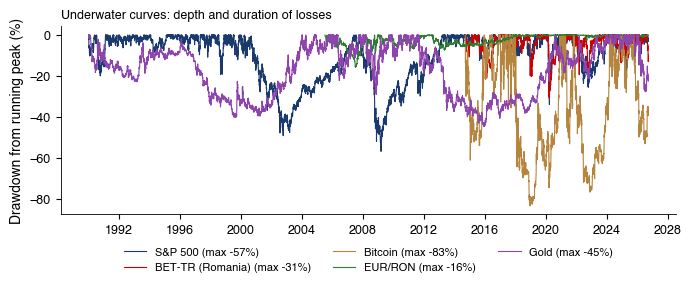

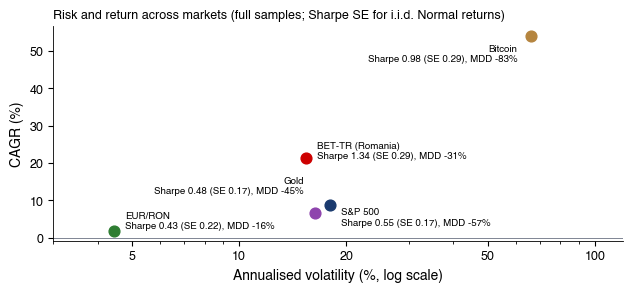

In [24]:
def fig_drawdowns():
    fig, ax = plt.subplots(figsize=(7.0, 3.0))
    for a in ASSETS:
        dd = drawdown(closes[a])
        ax.plot(dd.index, 100 * dd, color=COLORS[a], lw=0.8, label=f'{LABELS[a]} (max {100 * dd.min():.0f}%)')
    ax.set_ylabel('Drawdown from running peak (%)')
    ax.set_title('Underwater curves: depth and duration of losses', fontsize=9, loc='left')
    legend_outside_bottom(ax, ncol=3, y=-0.12)
    plt.tight_layout()
    save_fig('ch1_drawdowns')


def fig_risk_return(t):
    fig, ax = plt.subplots(figsize=(6.4, 3.0))
    for a in ASSETS:
        row = t.loc[LABELS[a]]
        ax.scatter(row['ann_vol_pct'], row['CAGR_pct'], s=60, color=COLORS[a], zorder=3)
        off = {'sp500': (8, -14), 'gold': (-8, 14), 'bettr': (8, 0), 'btc': (-10, -18), 'eurron': (8, 2)}[a]
        ax.annotate(f"{LABELS[a]}\nSharpe {row['Sharpe']:.2f} (SE {row['Sharpe_SE_Lo']:.2f}), MDD {row['maxDD_pct']:.0f}%",
                    (row['ann_vol_pct'], row['CAGR_pct']), xytext=off, textcoords='offset points', fontsize=7,
                    ha='right' if off[0] < 0 else 'left')
    ax.set_xscale('log')
    ax.set_xticks([5, 10, 20, 50, 100])
    ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{v:g}'))
    ax.xaxis.set_minor_formatter(plt.NullFormatter())
    ax.set_xlabel('Annualised volatility (%, log scale)')
    ax.set_ylabel('CAGR (%)')
    ax.set_xlim(3, 120)
    ax.axhline(0, color=Navy, lw=0.4)
    ax.set_title('Risk and return across markets (full samples; Sharpe SE for i.i.d. Normal returns)', fontsize=9, loc='left')
    plt.tight_layout()
    save_fig('ch1_risk_return')


fig_drawdowns()
fig_risk_return(rt)

## Conclusions

- Linear autocorrelations of returns are small, with market-specific exceptions (EUR/RON, lag 1 of the S&P 500); returns are not independent: their size is predictable.
- Heavy tails everywhere: 5σ days are more than 1000 times more frequent than under the Normal distribution.
- Volatility clusters, is highly persistent (long memory, persistent short memory or breaks remain open) and reacts to losses in equity markets (S&P 500 and BET-TR).
- Market structure matters: the managed EUR/RON rate and the less liquid Romanian market show positive autocorrelation.